¡Modelo entrenado con éxito!
Precisión (Accuracy): 0.9561

Modelo guardado exitosamente en: reports/svm_model.joblib


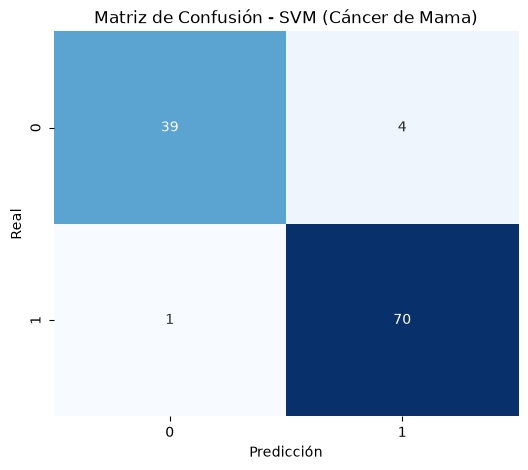

Gráfica guardada exitosamente en reports/confusion_matrix.png


In [2]:
import sys
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# 1. Asegurar la ruta del módulo src
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from inf8239_u01.data_loader import load_data

# 2. Cargar los datos y entrenar el modelo
df, target_names = load_data()
X = df.drop(columns=['target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = SVC(kernel='linear', random_state=42)
model.fit(X_train, y_train)

# 3. Evaluar
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"¡Modelo entrenado con éxito!")
print(f"Precisión (Accuracy): {accuracy:.4f}\n")

# 4. Guardar el modelo en la carpeta reports (Serialización)
os.makedirs('reports', exist_ok=True)
model_path = 'reports/svm_model.joblib'
joblib.dump(model, model_path)
print(f"Modelo guardado exitosamente en: {model_path}")

# 5. Generar y guardar la matriz de confusión visual
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión - SVM (Cáncer de Mama)')
plt.xlabel('Predicción')
plt.ylabel('Real')

plt.savefig('reports/confusion_matrix.png')
plt.show()
print("Gráfica guardada exitosamente en reports/confusion_matrix.png")